<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/cutout.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Cutout**

In [ ]:
!pip install astropy -q

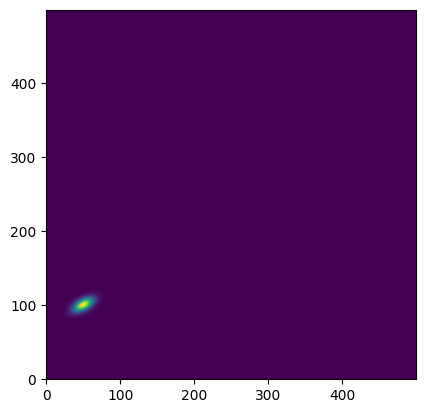

In [2]:
import numpy as np
from astropy.modeling.models import Gaussian2D
y, x = np.mgrid[0:500, 0:500]
data = Gaussian2D(1, 50, 100, 10, 5, theta=0.5)(x, y)

import matplotlib.pyplot as plt
plt.imshow(data, origin='lower')

The [cutout](https://docs.astropy.org/en/latest/nddata/utils.html) object can plot its bounding box on the original data using the plot_on_original() method:

<Axes: >

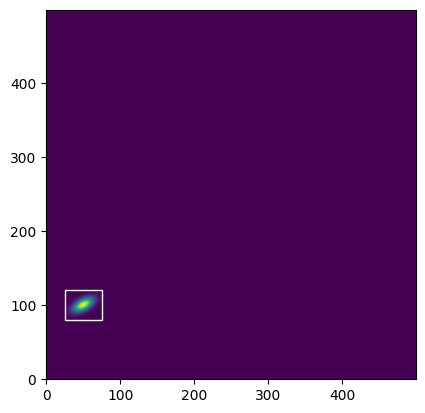

In [8]:
plt.imshow(data, origin='lower')
cutout.plot_on_original(color='white')

Next we can create a cutout for the single object in this image. We create a cutout centered at position (x, y) = (49.7, 100.1) with a size of (ny, nx) = (41, 51) pixels:

In [3]:
from astropy.nddata import Cutout2D
from astropy import units as u
position = (49.7, 100.1)
size = (41, 51)     # pixels
cutout = Cutout2D(data, position, size)

In [ ]:
# size keyword can also be a Quantity object:
size = u.Quantity((41, 51), u.pixel)
cutout = Cutout2D(data, position, size)

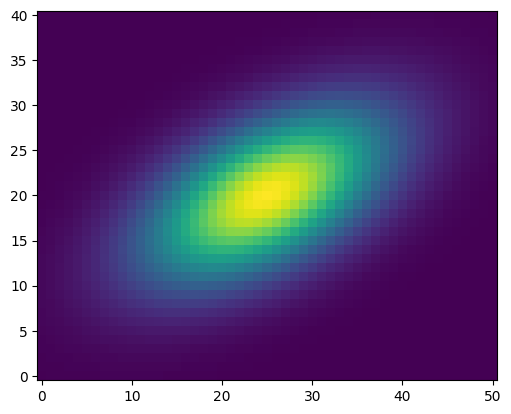

In [7]:
cutout = Cutout2D(data, position, (41, 51))
plt.imshow(cutout.data, origin='lower')

In [9]:
# Properties of the cutout array are also stored as attributes

# shape of the cutout array
print(cutout.shape)

# rounded pixel index of the input position
print(cutout.position_original)

# corresponding position in the cutout array
print(cutout.position_cutout)

# (non-rounded) input position in both the original and cutout arrays
print((cutout.input_position_original, cutout.input_position_cutout))

# the origin pixel in both arrays
print((cutout.origin_original, cutout.origin_cutout))

# tuple of slice objects for the original array
print(cutout.slices_original)

# tuple of slice objects for the cutout array
print(cutout.slices_cutout)

(41, 51)
(50, 100)
(25, 20)
((49.7, 100.1), (24.700000000000003, 20.099999999999994))
((25, 80), (0, 0))
(slice(80, 121, None), slice(25, 76, None))
(slice(0, 41, None), slice(0, 51, None))
